In [ ]:
import json
import re
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sys.path.append(str(Path.cwd().parent))
from utils import readjust_price, get_storey_mid

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"

resale = pd.read_csv(DATA_DIR / "merged_resale_prices.csv")
resale["month"] = pd.to_datetime(resale["month"])
resale["mid_floor"] = resale["storey_range"].apply(get_storey_mid)
coe = pd.read_csv(DATA_DIR / "COEBiddingResultsPrices.csv")



## COE momentum, not COE level

Two problems with using the raw COE *level* as the regressor:

1. **Timing** -- a resale purchase takes ~3-6 months from decision to registered completion, so
   the recorded `month` is the completion month, not when the buyer was weighing "cheap car vs.
   cheap flat." The COE level *at completion* may reflect a price set well after the relevant
   decision was made.
2. **Level isn't comparable across eras.** COE ranged from under $10k (2009) to over $150k
   (2013, 2023) over this window. A household isn't reacting to "COE is $90k" in the abstract --
   they're reacting to whether COE has been *rising or falling lately*. $90k means something
   completely different depending on whether it just fell from $140k or just rose from $40k, so
   the raw dollar level isn't really the right variable for "does COE affect this decision,"
   even setting the timing issue aside.

So the regressor used below is **COE momentum**: the % change in COE between two trailing
windows, both strictly before the transaction month (no centered/forward-looking window, which
would leak in COE information from after the decision was made):

    coe_pct_chg6 = (avg COE over months t-6..t-1) / (avg COE over months t-12..t-7) - 1

A positive value means COE has been rising over the past 6 months relative to the 6 months
before that; negative means it's been falling. This is unit-comparable across the whole
2010-2026 span in a way a raw dollar level or a raw dollar *change* isn't (a $20k swing means a
very different thing in 2012 vs. 2026, but a 20% swing means roughly the same thing either
year).

(`coe_a_avg6` / `coe_a_lag6` -- the trailing level and simple lag -- are also kept below purely
as a robustness cross-check against the momentum spec, not as the headline variable.)

In [8]:
coe["datetime"] = pd.to_datetime(coe["month"])
coe_cat_a = (
    coe[coe["vehicle_class"] == "Category A"]
    .groupby("datetime")["premium"]
    .mean()
    .rename("coe_a")
    .sort_index()
)

# Trailing 6-month average, strictly excluding the current month (shift(1) before rolling
# so month t only sees t-6..t-1, never t itself).
coe_a_avg6 = coe_cat_a.shift(1).rolling(window=6, min_periods=6).mean().rename("coe_a_avg6")

# Momentum: % change between the trailing 6mo window (t-6..t-1) and the 6mo window before
# that (t-12..t-7) -- both strictly pre-transaction, no look-ahead.
coe_a_avg6_prior = coe_a_avg6.shift(6).rename("coe_a_avg6_prior")
coe_pct_chg6 = (coe_a_avg6 / coe_a_avg6_prior - 1).rename("coe_pct_chg6")

coe_lagged = (
    pd.concat([coe_cat_a, coe_a_avg6, coe_pct_chg6], axis=1)
    .reset_index()
    .rename(columns={"datetime": "month"})
)
coe_lagged.tail(10)

,month,coe_a,coe_a_avg6,coe_pct_chg6
186,2025-10-01,125052.5,102790.500000,0.083089
187,2025-11-01,109501.0,107197.250000,0.138999
188,2025-12-01,107457.0,108321.583333,0.135133
189,2026-01-01,105755.0,109970.833333,0.147283
190,2026-02-01,106410.5,110746.333333,0.140595
191,2026-03-01,110055.0,111270.333333,0.118458
192,2026-04-01,120505.0,110705.166667,0.076998
193,2026-05-01,124509.5,109947.250000,0.025654
194,2026-06-01,124928.0,112448.666667,0.038100
195,2026-07-01,129000.0,115360.500000,0.049010


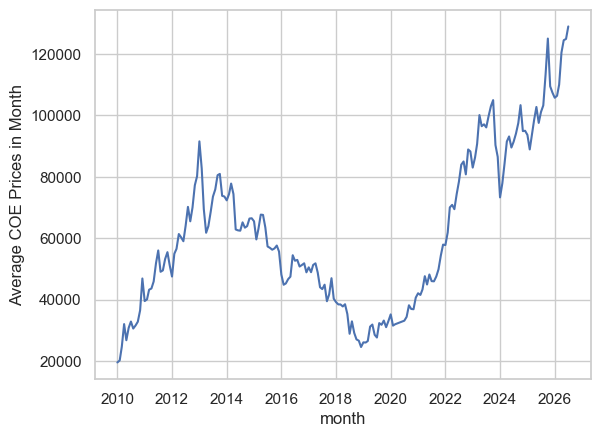

In [9]:
ax = sns.lineplot(data=coe_lagged, x= "month", y="coe_a")
ax.set_ylabel("Average COE Prices in Month")
plt.show()

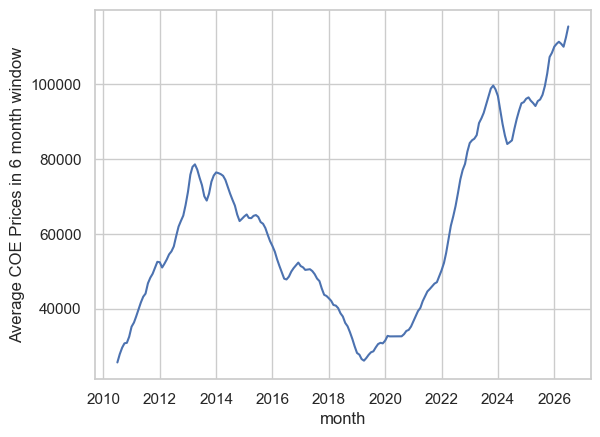

In [10]:
ax = sns.lineplot(data=coe_lagged, x= "month", y="coe_a_avg6")
ax.set_ylabel("Average COE Prices in 6 month window")
plt.show()

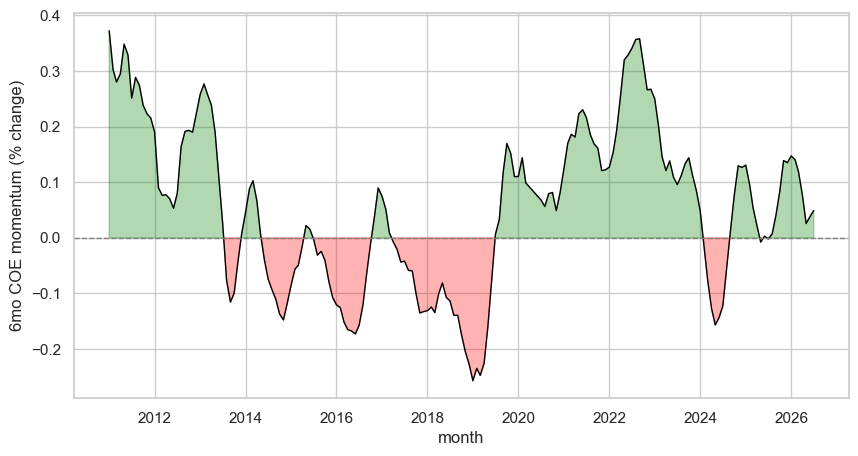

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=coe_lagged, x="month", y="coe_pct_chg6", ax=ax, color="black", linewidth=1)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.fill_between(
    coe_lagged["month"], coe_lagged["coe_pct_chg6"], 0,
    where=coe_lagged["coe_pct_chg6"] >= 0,
    color="green", alpha=0.3, interpolate=True,
)
ax.fill_between(
    coe_lagged["month"], coe_lagged["coe_pct_chg6"], 0,
    where=coe_lagged["coe_pct_chg6"] < 0,
    color="red", alpha=0.3, interpolate=True,
)

ax.set_ylabel("6mo COE momentum (% change)")
plt.show()

## Far towns
Some towns are chosen as examples for palces far away from city

In [16]:
far_towns = ["SEMBAWANG", "YISHUN", "WOODLANDS", "PUNGGOL", "SENGKANG", "PASIR RIS",
             "JURONG WEST", "JURONG EAST", "CHOA CHU KANG", "BUKIT BATOK",
             "BUKIT PANJANG", "TAMPINES"]

In [17]:
far_towns.sort()
far_towns

['BUKIT BATOK',
 'BUKIT PANJANG',
 'CHOA CHU KANG',
 'JURONG EAST',
 'JURONG WEST',
 'PASIR RIS',
 'PUNGGOL',
 'SEMBAWANG',
 'SENGKANG',
 'TAMPINES',
 'WOODLANDS',
 'YISHUN']

In [72]:
geo_df = gpd.read_file(DATA_DIR / "MasterPlan2019PlanningAreaBoundaryNoSea.geojson")

## Step 1: Merge COE (Category A) onto resale transactions by month

Category A (mass-market cars, <=1600cc/130bhp) is the category most relevant to an average
flat-buying household cross-shopping a car. COE data only starts 2010-01, so the merge
(`how="inner"`) naturally restricts the sample to 2010 onwards.

Monthly COE is averaged across the (usually two) bidding exercises per month.

In [20]:
resale_coe = resale.merge(coe_lagged, on="month", how="inner")
print(f"Sample: {resale_coe['month'].min().date()} to {resale_coe['month'].max().date()}, "
      f"n={len(resale_coe)}")
print(f"Rows dropped for missing lagged/momentum COE (first 12 months of coverage): "
      f"{resale_coe['coe_pct_chg6'].isna().sum()}")
resale_coe = resale_coe.dropna(subset=["coe_a_avg6", "coe_pct_chg6"]).copy()
print(f"Final sample after dropping: n={len(resale_coe)}")

Sample: 2010-01-01 to 2026-07-01, n=381603
Rows dropped for missing lagged/momentum COE (first 12 months of coverage): 34854
Final sample after dropping: n=346749


## Step 2: Build the far_town flag , log price
Linear regression assumes homoscedasticity and normality of residuals. Target variable Y is heavily right skewed, so trasnform with log


<Axes: xlabel='resale_price', ylabel='Count'>

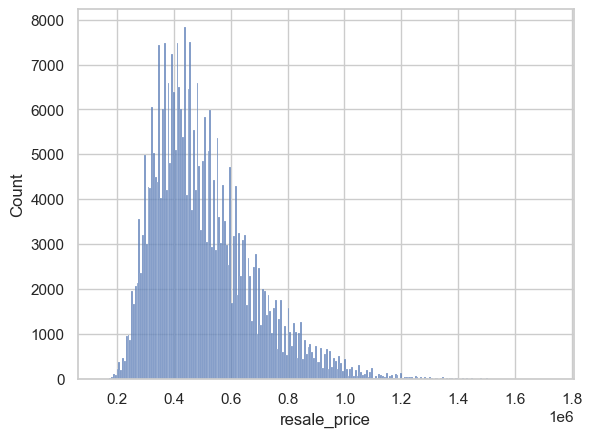

In [21]:
sns.histplot(resale_coe['resale_price'])

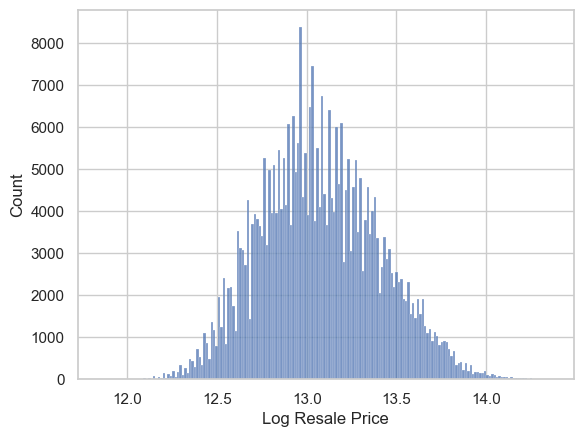

In [22]:
ax = sns.histplot(np.log(resale_coe['resale_price']))
ax.set_xlabel("Log Resale Price")
plt.show()

`far_town` is a 0/1 dummy from the (typo-fixed) `far_towns` list above.


In [23]:
resale_coe["far_town"] = resale_coe["town"].isin(far_towns)
resale_coe["log_price"] = np.log(resale_coe["resale_price"])
resale_coe["quarter"] = resale_coe["month"].dt.to_period("Q").astype(str)

print(f"Far towns: {resale_coe['far_town'].sum()} txns ({resale_coe['far_town'].mean():.1%})")
resale_coe.loc[resale_coe["far_town"], "town"].value_counts()

Far towns: 214473 txns (61.9%)


town
SENGKANG         26058
WOODLANDS        25941
JURONG WEST      24663
TAMPINES         24211
YISHUN           23092
PUNGGOL          20517
CHOA CHU KANG    15300
BUKIT BATOK      14601
BUKIT PANJANG    12328
PASIR RIS        10474
SEMBAWANG         9967
JURONG EAST       7321
Name: count, dtype: int64

## Step 3: Hedonic OLS with far_town x COE-momentum interaction

Model (run twice, log and level outcome, to compare):
```
    log(resale_price) ~ far_town * coe_pct_chg6 + C(flat_type) + C(flat_model) + C(town) 
                         + floor_area_sqm + flat_age_years + mid_floor
                         + C(quarter) + far_town + coe_pct_chg6
```
`coe_pct_chg6` is the % change in COE between the trailing 6-month window and the 6 months
before that (both strictly pre-transaction). The coefficient of interest is
`far_town[T.True]:coe_pct_chg6`: does far-town resale price move differently than the rest of
the market when COE has recently been rising vs. falling, after controlling for flat
characteristics?

- `C(quarter)` fixed effects absorb the shared market-wide cycle (cooling measures, interest
  rates, COVID) that moves both COE and resale prices together, so the interaction isn't
  picking up a spurious shared trend.
- `C(town)` fixed effects absorb permanent town-quality differences (Sengkang is just cheaper
  than Bishan for reasons unrelated to COE).
- **No RPI rescaling here**, unlike `dls2.ipynb`'s DTL2 analysis. There, RPI-rescaling was a
  substitute for quarter FE (the DTL2 spec estimates on raw price levels without quarter FE,
  so it needed RPI to strip out the market-wide trend some other way). Here we use quarter FE
  directly instead, which does the same job more precisely -- and RPI would actually be the
  wrong tool for *this* question specifically: RPI and COE both reflect the same broader
  economic cycle (income growth, credit conditions, asset prices), so deflating resale_price
  by RPI risks netting out part of the very COE relationship being tested. Quarter FE avoids
  that, since it isn't derived from a price index at all.
- SEs clustered by town, matching the DTL2 script's convention.

**Reading the interaction sign:**
- Positive & significant -> when COE has recently been *rising*, far-town prices rise *more*
  (or fall less) than the rest of the market -- consistent with buyers reacting to a recent COE
  run-up by bidding up cheaper, further-out flats to preserve car-buying budget.
- Negative or non-significant -> no support, or the opposite -- consistent with the separate
  correlation-based check in `question_coe_vs_suburban_prices.py`, which found a *negative*
  relationship for Sengkang+Punggol specifically (r ~ -0.23 to -0.29) using a similar
  YoY-%-change logic, just as a raw correlation rather than a controlled regression.

In [33]:
FORMULA_RHS = (
    "far_town * coe_pct_chg6 + C(flat_type) + C(flat_model) "
    "+ floor_area_sqm + flat_age_years + C(town) + C(quarter) + coe_pct_chg6 + far_town + mid_floor"
)

model_log = smf.ols(f"log_price ~ {FORMULA_RHS}", data=resale_coe).fit(
        cov_type="cluster", cov_kwds={"groups": resale_coe["town"]}
)


TERM = "far_town[T.True]:coe_pct_chg6"

coef, se, p = model_log.params[TERM], model_log.bse[TERM], model_log.pvalues[TERM]
print(f"{TERM}: {coef:+.5f} (se={se:.5f}, p={p:.3f})")

# coe_pct_chg6 is a proportion (0.10 = COE grew 10%), not a percentage-point count, so a
# "10-percentage-point rise" means the regressor moves by 0.10, not by 10. And since the
# outcome is log(price), the effect on price is (e^(coef*delta_x) - 1) * 100%, not a linear
# coef*delta_x*100 -- the two are close for small coefficients but not identical.
DELTA_X = 0.10
pct_effect = (np.exp(coef * DELTA_X) - 1) * 100
print(f"  -> a 10-percentage-point rise in 6mo COE growth (coe_pct_chg6 += 0.10, e.g. COE "
      f"growth going from 0%% to +10%%) is associated with far-town prices changing by "
      f"{pct_effect:+.2f}%% relative to the rest of the market, holding flat characteristics, "
      f"town, and quarter fixed.\n")


far_town[T.True]:coe_pct_chg6: +0.12393 (se=0.02214, p=0.000)
  -> a 10-percentage-point rise in 6mo COE growth (coe_pct_chg6 += 0.10, e.g. COE growth going from 0%% to +10%%) is associated with far-town prices changing by +1.25%% relative to the rest of the market, holding flat characteristics, town, and quarter fixed.



In [40]:
print(f"coef for far_town {model_log.params["far_town[T.True]"]} p-value for far_town {model_log.pvalues["far_town[T.True]"]}")
print(f"coef for coe {model_log.params["coe_pct_chg6"]} p-value for coe {model_log.pvalues["coe_pct_chg6"]}")

coef for far_town -0.19996690280386284 p-value for far_town 8.098987215366897e-42
coef for coe -0.05603949732989524 p-value for coe 0.002901112632951284


In [ ]:
rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")
resale_coe_rescaled = readjust_price(resale_coe, rpi, target_year=2026, target_quarter=3)
sns.histplot(np.log(resale_coe_rescaled["Rescale_price_2026_Q3"]))
sns.histplot(resale_coe_rescaled["Rescale_price_2026_Q3"])
resale_coe_rescaled["log_rescaled_price"] = np.log(resale_coe_rescaled["Rescale_price_2026_Q3"])
model = smf.ols(f"log_rescaled_price ~ {FORMULA_RHS}", data=resale_coe_rescaled).fit(
     cov_type="cluster", cov_kwds={"groups": resale_coe["town"]}
)


# See GDP
GDP could be a confounder


## GDP as a confounder check for the COE interaction

The `far_town:coe_pct_chg6` interaction has been positive and significant. But missing confounders may be present, such as the general economics of Singapore. COE bidding tracks car demand, which tracks disposable income and general economic confidence -- so `coe_pct_chg6` could just be a noisy proxy for "the economy is heating up," and far towns (younger estates, more first-time/budget buyers) may simply react more to the general economic cycle than mature estates, for reasons that have nothing to do with cars.

This dataset (`GDP At Current Market Prices`, YoY %% growth, quarterly) is a direct macro-cycle
measure, independent of COE. Unlike COE, it's already a YoY growth rate, not a raw level, so no
separate momentum transform is needed -- just reshape from wide (one column per quarter) to
long, and align each transaction's quarter to it.

**The test**: put `far_town * coe_pct_chg6` and `far_town * gdp_growth` in the *same* regression
(not two separate models) -- that's what lets GDP compete with COE for whatever variance it's
explaining.

- If `far_town:coe_pct_chg6` shrinks toward zero / loses significance once
  `far_town:gdp_growth` is added -> COE was likely proxying for the general economic cycle, not
  a car-specific effect.
- If `far_town:coe_pct_chg6` stays roughly the same size and significant, while
  `far_town:gdp_growth` is small/insignificant -> the COE-specific story survives independently
  of general GDP conditions.
- If both are significant -> both matter, and the effect isn't fully attributable to either one
  alone.

In [56]:
gdp = pd.read_csv(DATA_DIR / "GrossDomesticProductYearOnYearGrowthRateQuarterly.csv")
gdp_headline = gdp[gdp["DataSeries"] == "GDP At Current Market Prices"].drop(columns="DataSeries")

# Column labels look like "20261Q" (year + quarter digit, quarter last) -- convert to a
# pandas Period("2026Q1") string to match resale_coe["quarter"]'s "2026Q1" format.
def to_period_str(col):
    year, q = col[:4], col[4]
    return f"{year}Q{q}"

gdp_long = (
    gdp_headline.melt(var_name="raw_quarter", value_name="gdp_growth")
    .assign(quarter=lambda d: d["raw_quarter"].map(to_period_str))
    .drop(columns="raw_quarter")
    .astype({"gdp_growth": float})
    .sort_values("quarter")
    .reset_index(drop=True)
)
print(f"GDP coverage: {gdp_long['quarter'].min()} to {gdp_long['quarter'].max()}")
gdp_long.tail()

GDP coverage: 1976Q1 to 2026Q1


,gdp_growth,quarter
196,5.5,2025Q1
197,3.4,2025Q2
198,0.7,2025Q3
199,3.2,2025Q4
200,6.9,2026Q1


C:\Users\zheng\AppData\Local\Temp\ipykernel_24924\1385802267.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdp_long_dt = gdp_long.assign(quarter_dt=pd.to_datetime(gdp_long["quarter"]))


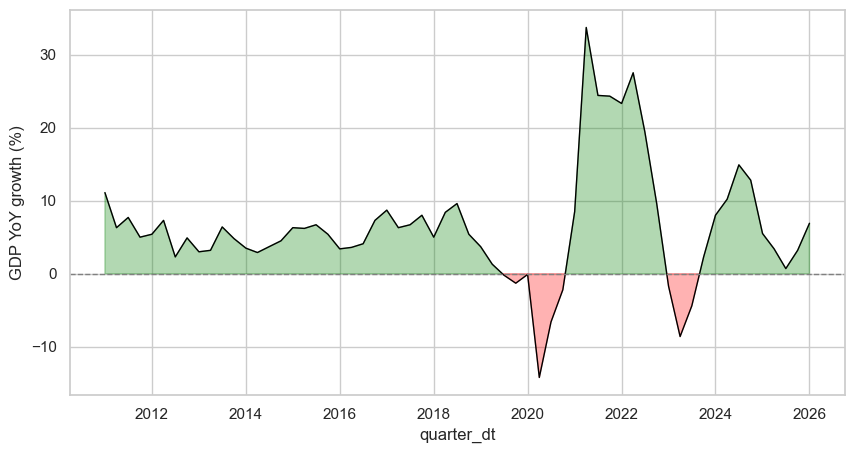

In [54]:
gdp_long_dt = gdp_long.assign(quarter_dt=pd.to_datetime(gdp_long["quarter"]))
gdp_long_dt = gdp_long_dt[gdp_long_dt.quarter_dt.dt.year>2010]
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=gdp_long_dt, x="quarter_dt", y="gdp_growth", ax=ax, color="black", linewidth=1)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.fill_between(
    gdp_long_dt["quarter_dt"], gdp_long_dt["gdp_growth"], 0,
    where=gdp_long_dt["gdp_growth"] >= 0,
    color="green", alpha=0.3, interpolate=True,
)
ax.fill_between(
    gdp_long_dt["quarter_dt"], gdp_long_dt["gdp_growth"], 0,
    where=gdp_long_dt["gdp_growth"] < 0,
    color="red", alpha=0.3, interpolate=True,
)

ax.set_ylabel("GDP YoY growth (%)")
plt.show()

In [57]:
resale_coe_gdp = resale_coe.merge(gdp_long, on="quarter", how="inner")
print(f"Rows before GDP merge: {len(resale_coe)}, after: {len(resale_coe_gdp)}")

confound_rhs = (
    "far_town * coe_pct_chg6 + far_town * gdp_growth + C(flat_type) + C(flat_model)+ coe_pct_chg6  "
    "+ floor_area_sqm + flat_age_years + C(town) + C(quarter) + gdp_growth + far_town + mid_floor"
)
confound_model = smf.ols(f"log_price ~ {confound_rhs}", data=resale_coe_gdp).fit(
    cov_type="cluster", cov_kwds={"groups": resale_coe_gdp["town"]}
)

for term in ["far_town[T.True]:coe_pct_chg6", "far_town[T.True]:gdp_growth"]:
    coef, se, p = confound_model.params[term], confound_model.bse[term], confound_model.pvalues[term]
    print(f"{term}: {coef:+.5f} (se={se:.5f}, p={p:.3f})")

Rows before GDP merge: 346749, after: 339712
far_town[T.True]:coe_pct_chg6: +0.12393 (se=0.02175, p=0.000)
far_town[T.True]:gdp_growth: +0.00004 (se=0.00023, p=0.848)


In [61]:
print(f"coef for far_town {confound_model.params["far_town[T.True]"]} p-value for far_town {confound_model.pvalues["far_town[T.True]"]}")
print(f"coef for coe {confound_model.params["coe_pct_chg6"]} p-value for coe {confound_model.pvalues["coe_pct_chg6"]}")
print(f"coef for gdp {confound_model.params["gdp_growth"]} p-value for coe {confound_model.pvalues["gdp_growth"]}")

coef for far_town -0.20011973839338698 p-value for far_town 2.0626590143115706e-42
coef for coe -0.056202866846168334 p-value for coe 0.0029191221933865343
coef for gdp 0.018895901807680686 p-value for coe 0.0
